# Comprendre l'entrée de LayoutLMv3

Objectif :

Comprendre exactement quelles informations sont envoyées au modèle avant le fine-tuning.

À la fin de ce notebook, je dois être capable d'expliquer :

- pourquoi un OCR est nécessaire ;
- ce que produit l'OCR ;
- ce que reçoit LayoutLMv3 ;
- pourquoi des annotations sont nécessaires.

PDF
   │
   ▼
PyMuPDF (fitz)
   │
   ▼
Image
   │
   ▼
Tesseract
   │
   ├── Texte
   ├── Bounding boxes
   └── Scores de confiance
           │
           ▼
      LayoutLMv3

In [1]:
from pathlib import Path

import pytesseract
import pymupdf

from PIL import Image
import matplotlib.pyplot as plt

In [7]:
from pathlib import Path

import pymupdf
from PIL import Image


pdf_path = Path("../benchmarks/ocr/input/devis_2.pdf")

doc = pymupdf.open(pdf_path)

try:
    page = doc[0]

    pix = page.get_pixmap(
        matrix=pymupdf.Matrix(2, 2),
        alpha=False,
    )

    image = Image.frombytes(
        "RGB",
        [pix.width, pix.height],
        pix.samples,
    )

    print("Image générée :", image.size)

finally:
    doc.close()

Image générée : (1191, 1684)


In [3]:
from pytesseract import Output

ocr_data = pytesseract.image_to_data(
    image,
    lang="fra",
    output_type=Output.DICT,
    config="--oem 1 --psm 3",
)

print(ocr_data.keys())

dict_keys(['level', 'page_num', 'block_num', 'par_num', 'line_num', 'word_num', 'left', 'top', 'width', 'height', 'conf', 'text'])


In [4]:
words = []

for index, raw_text in enumerate(ocr_data["text"]):
    text = raw_text.strip()
    confidence = float(ocr_data["conf"][index])

    # Tesseract contient aussi des lignes représentant
    # des pages, blocs ou paragraphes sans texte.
    if not text or confidence < 0:
        continue

    left = int(ocr_data["left"][index])
    top = int(ocr_data["top"][index])
    width = int(ocr_data["width"][index])
    height = int(ocr_data["height"][index])

    words.append(
        {
            "text": text,
            "confidence": round(confidence / 100, 4),
            "bbox": [
                left,
                top,
                left + width,
                top + height,
            ],
        }
    )

words[:20]

[{'text': 'Cäblage', 'confidence': 0.5, 'bbox': [164, 214, 200, 229]},
 {'text': 'Maintens', 'confidence': 0.41, 'bbox': [211, 214, 253, 229]},
 {'text': 'Offre', 'confidence': 0.95, 'bbox': [103, 366, 197, 400]},
 {'text': 'de', 'confidence': 0.95, 'bbox': [210, 366, 252, 394]},
 {'text': 'prix', 'confidence': 0.96, 'bbox': [260, 366, 343, 401]},
 {'text': 'n°', 'confidence': 0.85, 'bbox': [356, 368, 415, 395]},
 {'text': ':', 'confidence': 0.85, 'bbox': [403, 362, 418, 405]},
 {'text': '002.143/25', 'confidence': 0.91, 'bbox': [429, 366, 616, 395]},
 {'text': 'Affaire', 'confidence': 0.93, 'bbox': [97, 414, 173, 437]},
 {'text': ':', 'confidence': 0.91, 'bbox': [180, 421, 186, 433]},
 {'text': 'A24013', 'confidence': 0.92, 'bbox': [192, 415, 278, 433]},
 {'text': 'CHEVAL', 'confidence': 0.96, 'bbox': [286, 415, 388, 433]},
 {'text': 'Devis', 'confidence': 0.91, 'bbox': [99, 453, 157, 472]},
 {'text': 'effectué', 'confidence': 0.96, 'bbox': [165, 453, 246, 476]},
 {'text': 'par', 'con

Les coordonnées sont normalisées entre 0 et 1000 afin que le modèle apprenne la position relative des éléments dans la page, indépendamment de la résolution ou de la taille du document. Le choix de 1000 est une convention adoptée par la famille LayoutLM, offrant une précision suffisante tout en conservant des coordonnées entières.

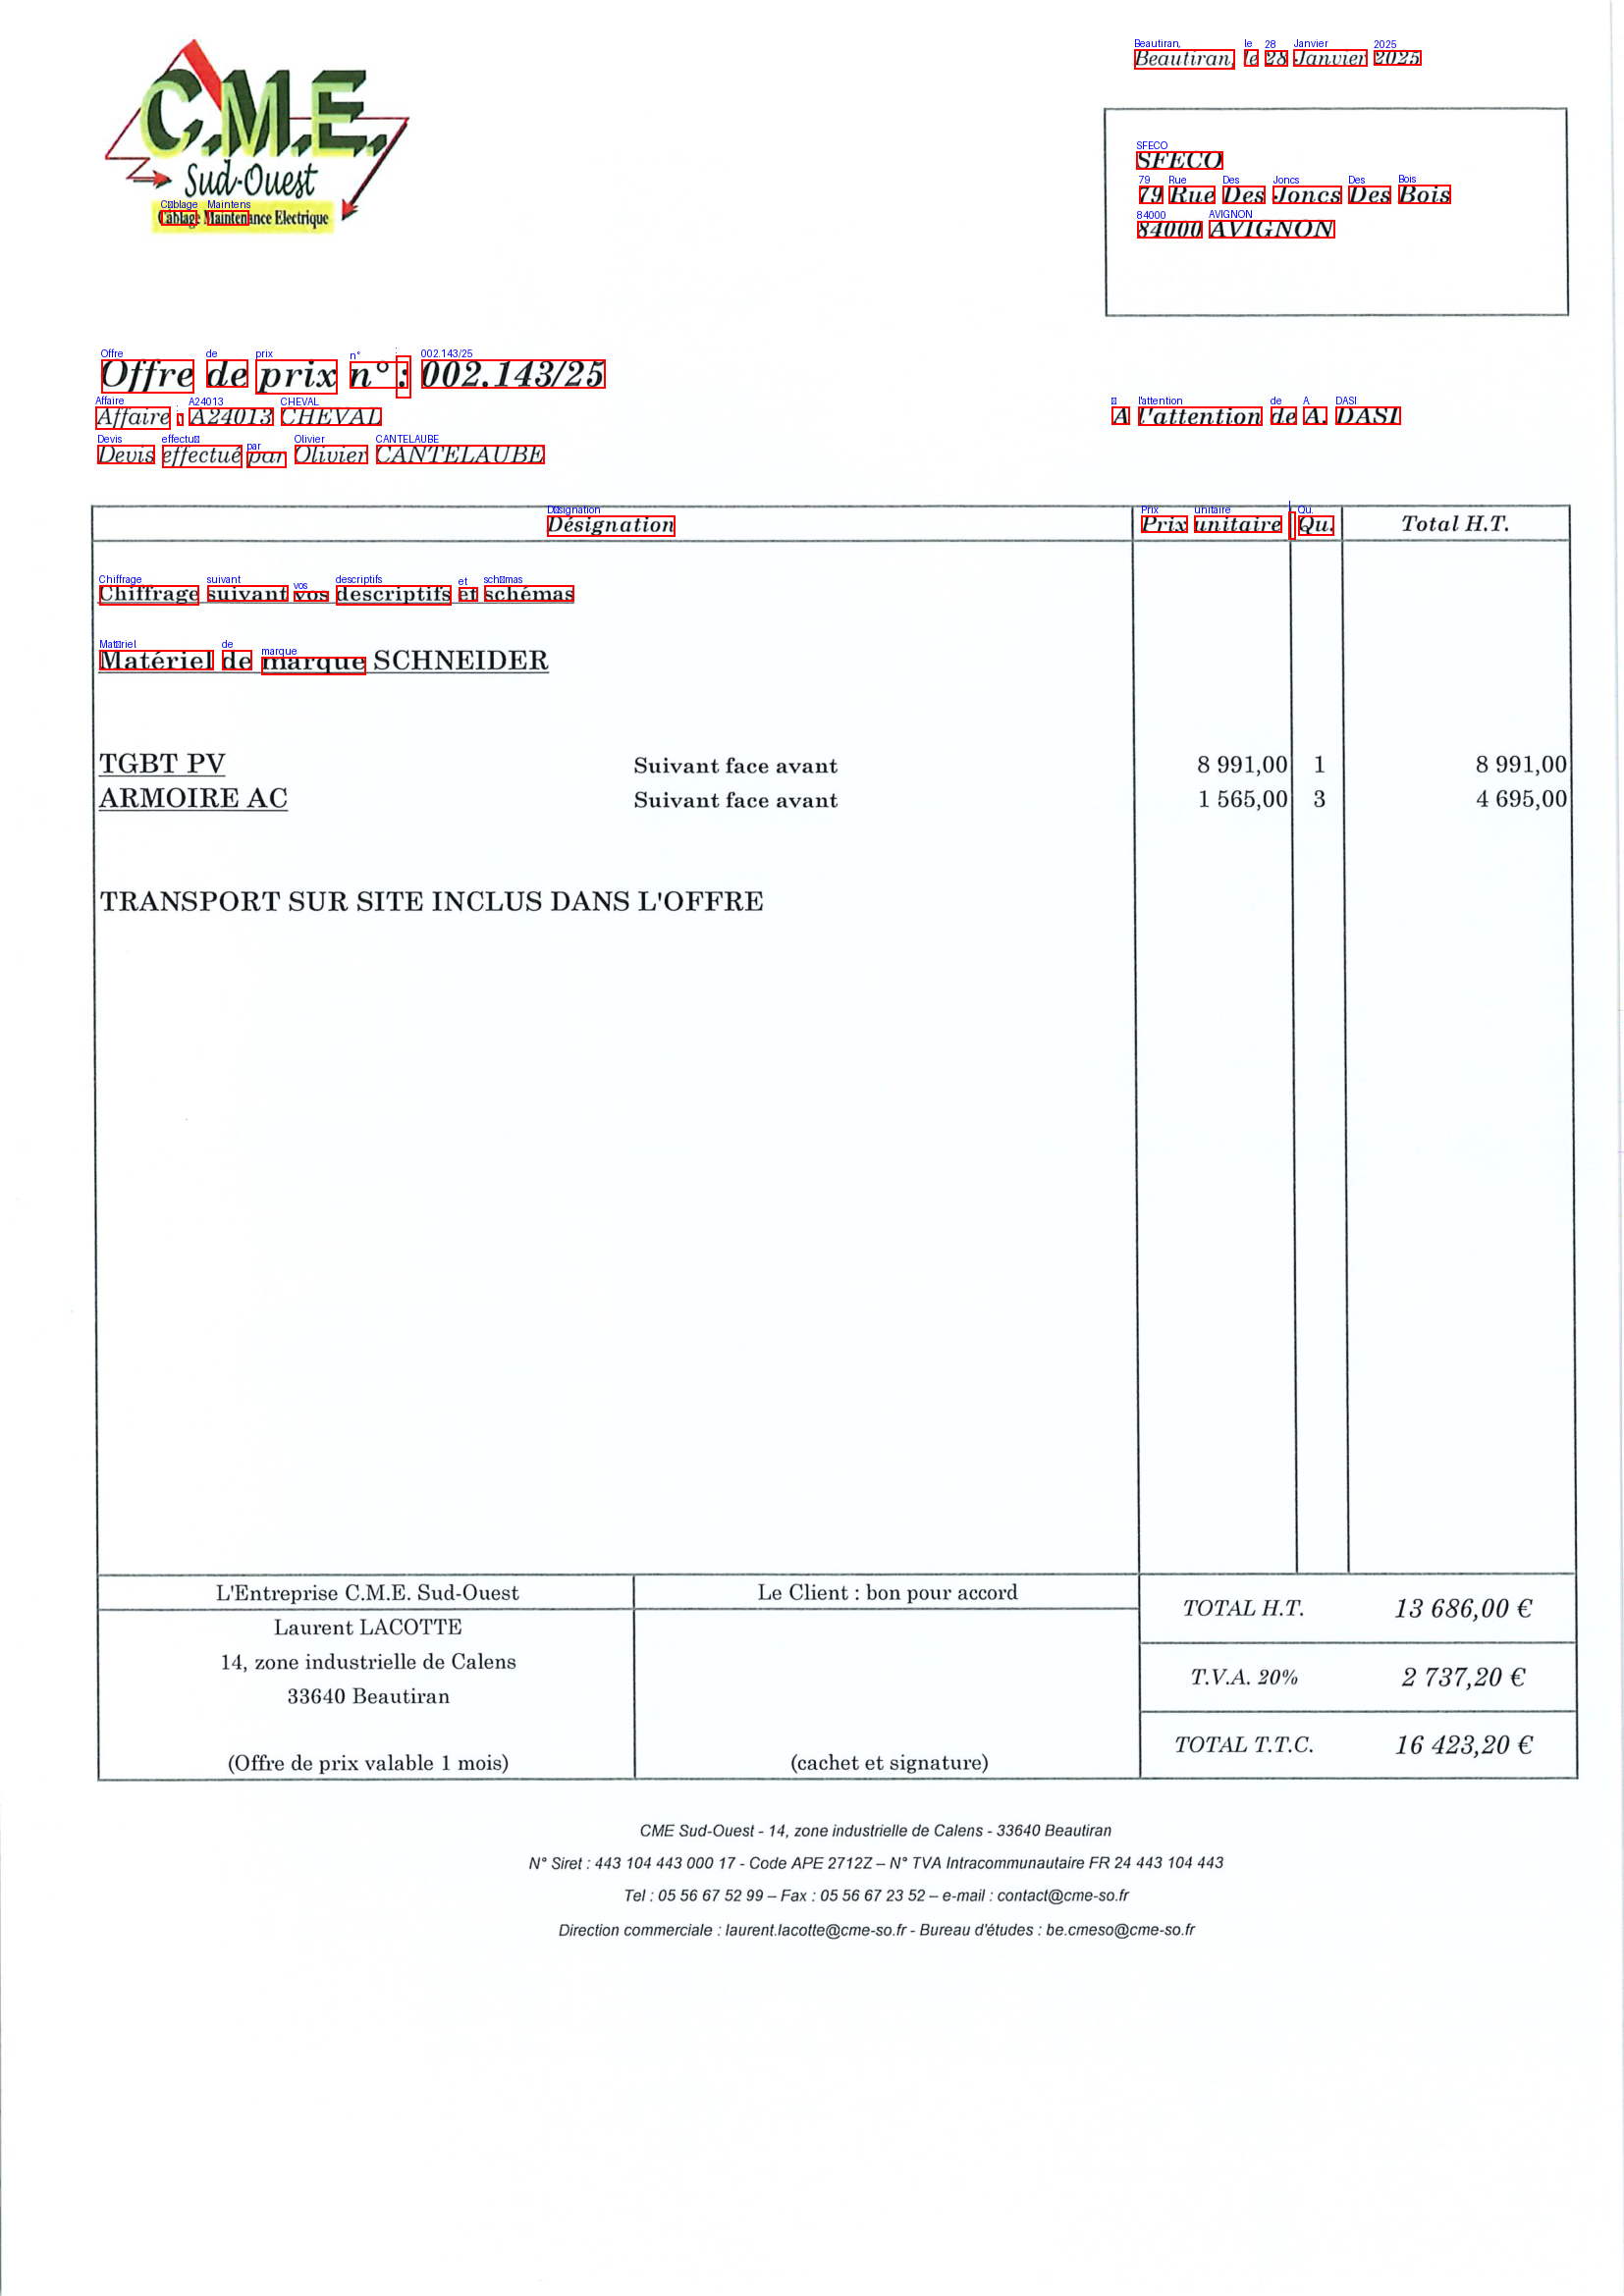

In [5]:
from PIL import ImageDraw

image_boxes = image.copy()

draw = ImageDraw.Draw(image_boxes)

for word in words[:50]:

    x1, y1, x2, y2 = word["bbox"]

    draw.rectangle(
        [(x1, y1), (x2, y2)],
        outline="red",
        width=2,
    )

    draw.text(
        (x1, y1 - 12),
        word["text"],
        fill="blue",
    )

image_boxes

Bien sûr. Voici un résumé dédié **uniquement** au notebook **`02_understanding_layoutlmv3_input.ipynb`**. L'objectif est qu'il puisse servir de notes de cours, de support de reprise et de préparation à la soutenance.

---

# Notebook 02 — Comprendre l'entrée de LayoutLMv3

## Objectif

L'objectif de ce notebook n'est **pas** d'entraîner un modèle ni de réaliser des annotations.

L'objectif est de répondre à une question fondamentale :

> **Quelles sont exactement les données reçues par LayoutLMv3 ?**

Avant de construire un pipeline de Deep Learning, il est indispensable de comprendre les données manipulées par le modèle.

---

# Position dans le pipeline

```text
Benchmark OCR
        │
        ▼
Comprendre l'entrée de LayoutLMv3  ← Notebook 02
        │
        ▼
Préparation Label Studio
        │
        ▼
Annotations
        │
        ▼
Fine-tuning
```

Ce notebook est un notebook de **compréhension**, pas de développement.

---

# 1. LayoutLMv3 ne reçoit pas directement un PDF

Un PDF n'est pas exploitable directement par LayoutLMv3.

La première étape consiste donc à convertir le PDF en image.

Nous avons utilisé **PyMuPDF** (`pymupdf`).

Pipeline :

```text
PDF
    │
    ▼
PyMuPDF
    │
    ▼
Image
```

### Pourquoi PyMuPDF ?

Nous avons retenu PyMuPDF car il offre :

* un rendu très fidèle ;
* un contrôle du DPI ;
* de bonnes performances ;
* une utilisation courante dans les projets de Document AI.

Cette bibliothèque n'est pas une dépendance de LayoutLMv3, mais une brique de notre pipeline.

---

# 2. Pourquoi un OCR est nécessaire

LayoutLMv3 ne sait pas lire directement les caractères présents dans une image.

Nous devons donc utiliser un OCR.

Après notre benchmark scientifique (WER, CER, vitesse d'exécution), nous avons retenu **Tesseract** pour le projet Alyra.

L'objectif de l'OCR est de transformer une image en informations structurées.

Pipeline :

```text
Image
      │
      ▼
Tesseract
```

---

# 3. Ce que produit réellement un OCR

Au départ, nous pensions que l'OCR produisait uniquement du texte.

En réalité, il produit beaucoup plus.

La structure renvoyée par Tesseract est :

```python
dict_keys([
    'level',
    'page_num',
    'block_num',
    'par_num',
    'line_num',
    'word_num',
    'left',
    'top',
    'width',
    'height',
    'conf',
    'text'
])
```

Nous avons ensuite construit une structure plus simple :

```python
{
    "text": "...",
    "confidence": ...,
    "bbox": [...]
}
```

Exemple :

```python
{
    "text": "CHEVAL",
    "confidence": 0.96,
    "bbox": [286,415,388,433]
}
```

Nous avons compris que l'OCR ne renvoie pas un texte continu mais une **collection de tokens**.

---

# 4. Les Bounding Boxes

Chaque token est associé à une bounding box.

Format :

```text
[x_min,
 y_min,
 x_max,
 y_max]
```

Ces coordonnées indiquent précisément où se trouve le mot sur le document.

Nous avons compris que LayoutLMv3 apprend non seulement le contenu des mots mais également leur position.

---

# 5. Pourquoi normaliser les coordonnées

Les coordonnées de Tesseract sont exprimées en pixels.

Or la taille des documents varie :

* résolution différente ;
* scanner différent ;
* qualité différente.

Nous avons donc compris pourquoi LayoutLM normalise les coordonnées.

Les coordonnées sont converties dans un espace commun :

```text
0
│
│
1000
```

Ainsi :

* un document de 1500 px ;
* un document de 3000 px ;

produisent exactement les mêmes coordonnées relatives.

Le choix de 1000 est une convention de la famille LayoutLM.

---

# 6. Le rôle de l'image

Nous avons compris que LayoutLMv3 combine trois sources d'information.

## Le texte

Exemple :

```text
TOTAL
```

---

## Les positions

Exemple :

```text
(820,1450)
```

---

## L'image

L'image apporte des informations absentes des tokens :

* tableaux ;
* bordures ;
* logos ;
* taille des caractères ;
* texte en gras ;
* alignements ;
* éléments graphiques.

Nous avons retenu la phrase suivante :

> **Les tokens disent "quoi", les bounding boxes disent "où", et l'image apporte le contexte visuel.**

---

# 7. Visualisation des bounding boxes

Nous avons dessiné les rectangles directement sur le devis.

Cette étape a été essentielle.

Elle nous a permis de comprendre que LayoutLMv3 ne "voit" plus un devis.

Il voit une collection de mots géolocalisés.

Exemple :

```text
Offre

de

prix

002.143/25

CHEVAL
```

Chaque mot possède une position précise.

---

# 8. Le véritable rôle des annotations

Avant cette séance, nous pensions que les annotations consistaient à dessiner des rectangles.

En réalité :

Les rectangles existent déjà.

Ils sont produits par l'OCR.

Notre travail consiste uniquement à ajouter une information supplémentaire.

Exemple :

Avant :

```python
{
    "text":"CHEVAL",
    "bbox":[...]
}
```

Après annotation :

```python
{
    "text":"CHEVAL",
    "bbox":[...],
    "label":"CUSTOMER"
}
```

Nous avons compris que l'annotation est en réalité une **classification de tokens**.

---

# 9. Ce que reçoit réellement LayoutLMv3

Pendant le fine-tuning :

```text
Image

+

Tokens

+

Bounding Boxes

+

Labels
```

Pendant l'inférence :

```text
Image

+

Tokens

+

Bounding Boxes
```

Le modèle doit alors prédire les labels.

---

# 10. Les principaux déclics

Au cours de ce notebook, plusieurs idées importantes ont émergé :

### Déclic 1

Le PDF n'est jamais directement envoyé au modèle.

---

### Déclic 2

L'OCR ne produit pas uniquement du texte.

Il produit :

* des tokens ;
* leurs positions ;
* un score de confiance.

---

### Déclic 3

Les annotations ne servent pas à détecter les mots.

Elles servent uniquement à leur attribuer une classe métier.

---

### Déclic 4

LayoutLMv3 ne lit pas un document comme un humain.

Il manipule des **tokens géolocalisés** enrichis par les informations visuelles de l'image.

---

# Schéma récapitulatif

```text
PDF
        │
        ▼
PyMuPDF
        │
        ▼
Image
        │
        ▼
Tesseract
        │
        ├── Tokens
        ├── Bounding Boxes
        └── Scores OCR
                │
                ▼
Préparation des données
                │
                ▼
Annotations (Labels)
                │
                ▼
Entrée de LayoutLMv3
```

---

# Ce qu'il faut retenir pour la soutenance

Si je devais résumer ce notebook en quelques phrases, je dirais :

1. **LayoutLMv3 ne reçoit jamais directement un PDF.** Le document est d'abord converti en image.
2. **L'OCR est une étape indispensable** pour extraire les tokens et leurs positions.
3. **Les bounding boxes sont normalisées** afin de rendre le modèle indépendant de la résolution des documents.
4. **LayoutLMv3 combine trois modalités** : le texte, la position des mots et les informations visuelles de l'image.
5. **L'annotation ne consiste pas à dessiner des rectangles**, mais à attribuer des labels métier aux tokens détectés par l'OCR.
6. **Ce notebook avait pour objectif de comprendre le fonctionnement du modèle**, pas de construire un pipeline de production. Cette compréhension est indispensable avant de préparer les données, d'annoter les documents et de lancer le fine-tuning.
